<a href="https://colab.research.google.com/github/budvindesilva/ENM532_Final_Proj/blob/main/ENM532_Drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Author
#Budvin De Silva (University of Pennsylvania)

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Values From Julian Forster (ETH Zurich)
# System Identication of the Crazy Flie 2.0 Nano Quadrocopter

m    = 0.025        # kg
Ixx  = 1.657171e-5  # kg·m²
Iyy  = 1.657171e-5  # kg·m²
Izz  = 2.926165e-5  # kg·m²
d    = 0.046        # m (arm length)
cT   = 1.28192e-8   # N·s²/rad²
cQ   = 7.6517e-11   # N·m·s²/rad²
g    = 9.81         # m/s²


In [ ]:
def quadrotor_ode(t, state, inputs):
    x, y, z, xd, yd, zd, phi, theta, psi, p, q, r = state
    T, tau1, tau2, tau3 = inputs

    # phi, theta, psi are Euler angles (inertial frame, ZYX convention)
    cphi, sphi = np.cos(phi), np.sin(phi)
    cth, sth = np.cos(theta), np.sin(theta)
    cpsi, spsi = np.cos(psi), np.sin(psi)

    tth = np.tan(theta)

    #The rate of the Euler Angles
    #The kinematic equations relating body rates to Euler angle rates follow Stevens, Lewis & Johnson (2015), equation (1.4-4)
    phid = p + q * (sphi * tth)  + r*cphi*tth #phi_dot
    thetad = q * cphi - r *sphi  #theta_dot
    psid = q*sphi/cth + r*cphi/cth #psi_dot

    #Body Rate derivatives from Mahony
    #Remember regular p, q, r are angular velocites from the body frame
    pdot = ((Iyy - Izz)/Ixx)*q*r + tau1/Ixx
    qdot = ((Izz - Ixx)/Iyy)*p*r + tau2/Iyy
    rdot = ((Ixx - Iyy)/Izz)*q*p + tau3/Izz


    #How fast the drone is accelerating among each axis
    xdd = (T/m) * (cpsi*sth + cth*sphi*spsi)     #acceleration in the x (intertial reference frame Z-X-Y)
    ydd = (T/m) *(spsi*sth - cpsi*cth*sphi)      #acceleration in the y (intertial reference frame Z-X-Y)
    zdd = (T/m) * (cphi*cth) - g                 #acceleration in the z (intertial reference frame Z-X-Y)

    return [xd, yd, zd,           # derivatives of position
        xdd, ydd, zdd,            # derivatives of velocity
        phid, thetad, psid,       # derivatives of Euler angles
        pdot, qdot, rdot]         # derivatives of body rates


In [ ]:
# Initial Conditions
state0 = [0, 0, 0,      #position
          0, 0, 0,      #velocity
          0, 0, 0,      #euler angles
          0, 0, 0]      #angular velocity in the body frame


In [ ]:
def inputs(t):
    T    = m * g
    tau1 = 2e-5 * np.sin(2 * 2*np.pi * t)    # 10x larger
    tau2 = 2e-5 * np.sin(2.3 * 2*np.pi * t)
    tau3 = 2e-5 * np.sin(3 * 2*np.pi * t)
    return [T, tau1, tau2, tau3]

In [ ]:
t_span = (0, 5)
t_eval = np.linspace(0, 5, 1000)

In [ ]:
sol = solve_ivp(lambda t, s: quadrotor_ode(t, s, inputs(t)), t_span, state0, t_eval=t_eval,
                method='RK45', rtol=1e-8, atol=1e-10)

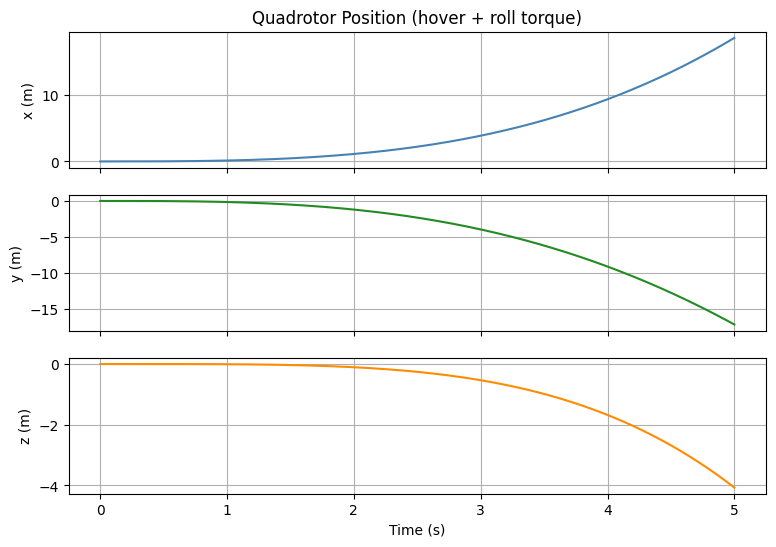

In [ ]:
ig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

axes[0].plot(sol.t, sol.y[0], color='steelblue')
axes[0].set_ylabel('x (m)')
axes[0].set_title('Quadrotor Position (hover + roll torque)')
axes[0].grid(True)

axes[1].plot(sol.t, sol.y[1], color='forestgreen')
axes[1].set_ylabel('y (m)')
axes[1].grid(True)

axes[2].plot(sol.t, sol.y[2], color='darkorange')
axes[2].set_ylabel('z (m)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True)


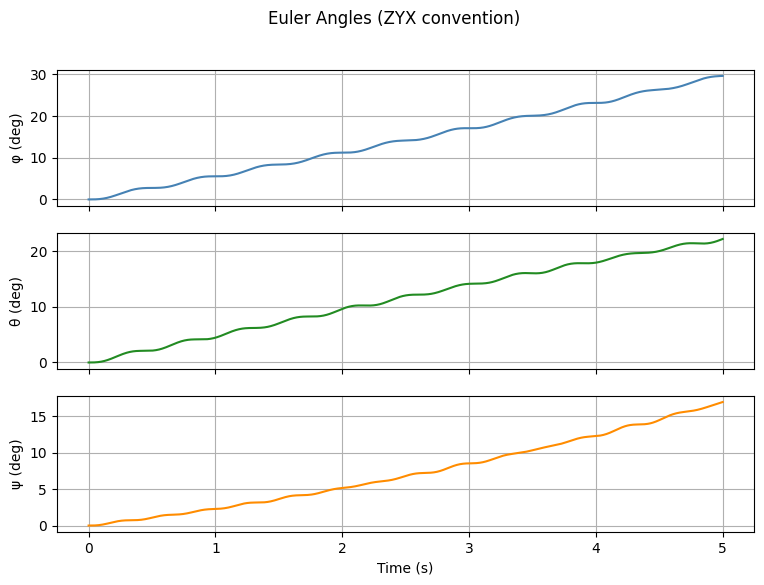

In [ ]:
fig2, axes2 = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
fig2.suptitle('Euler Angles (ZYX convention)')
axes2[0].plot(sol.t, np.degrees(sol.y[6]), color='steelblue')
axes2[0].set_ylabel('φ (deg)')
axes2[0].grid(True)
axes2[1].plot(sol.t, np.degrees(sol.y[7]), color='forestgreen')
axes2[1].set_ylabel('θ (deg)')
axes2[1].grid(True)
axes2[2].plot(sol.t, np.degrees(sol.y[8]), color='darkorange')
axes2[2].set_ylabel('ψ (deg)')
axes2[2].set_xlabel('Time (s)')
axes2[2].grid(True)


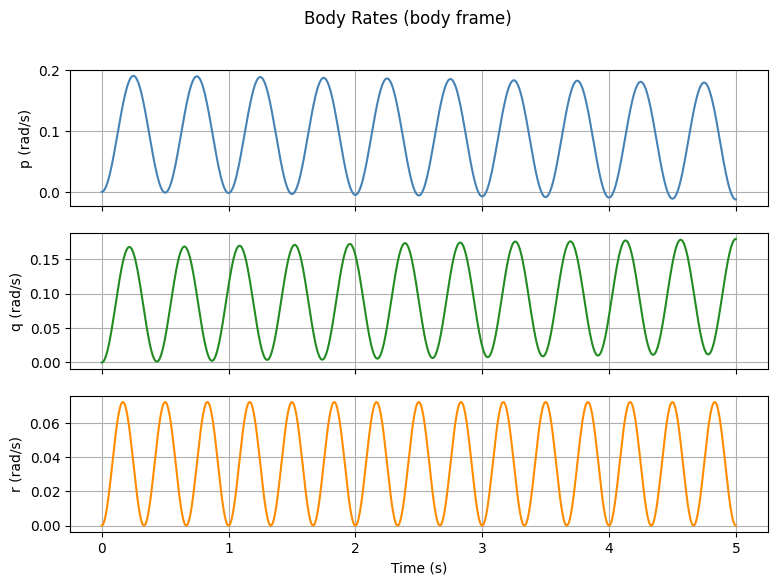

In [ ]:

fig3, axes3 = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
fig3.suptitle('Body Rates (body frame)')
axes3[0].plot(sol.t, sol.y[9], color='steelblue')
axes3[0].set_ylabel('p (rad/s)')
axes3[0].grid(True)
axes3[1].plot(sol.t, sol.y[10], color='forestgreen')
axes3[1].set_ylabel('q (rad/s)')
axes3[1].grid(True)
axes3[2].plot(sol.t, sol.y[11], color='darkorange')
axes3[2].set_ylabel('r (rad/s)')
axes3[2].set_xlabel('Time (s)')
axes3[2].grid(True)
